
--- Age Statistics ---
Mean: 52.88 | Variance: 438.84 | Skewness: -0.01 | Kurtosis: -1.22

--- BMI Statistics ---
Mean: 29.21 | Variance: 38.36 | Skewness: 0.06 | Kurtosis: -1.20


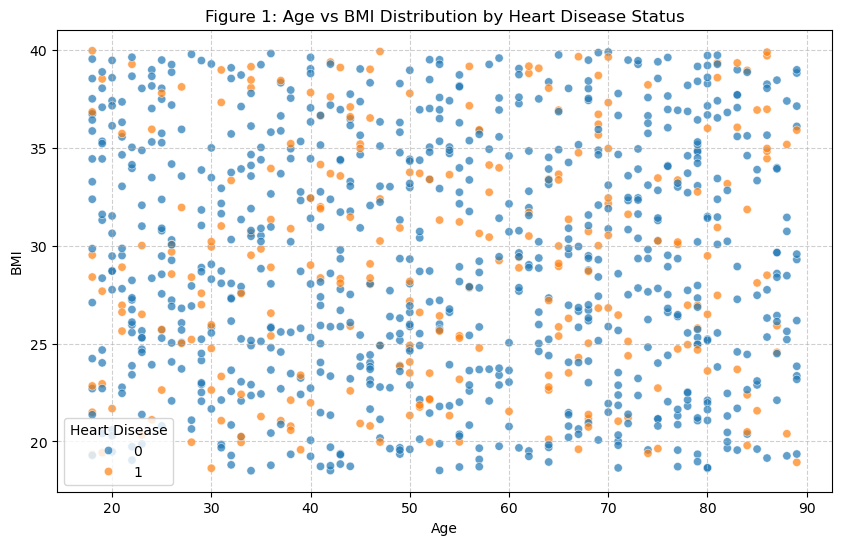

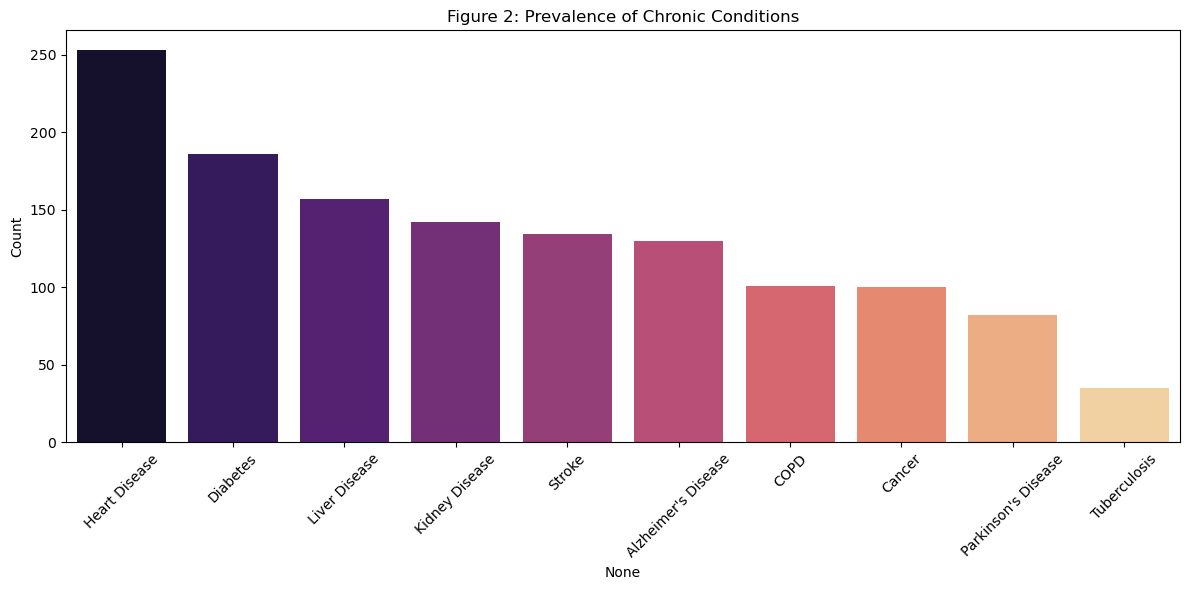

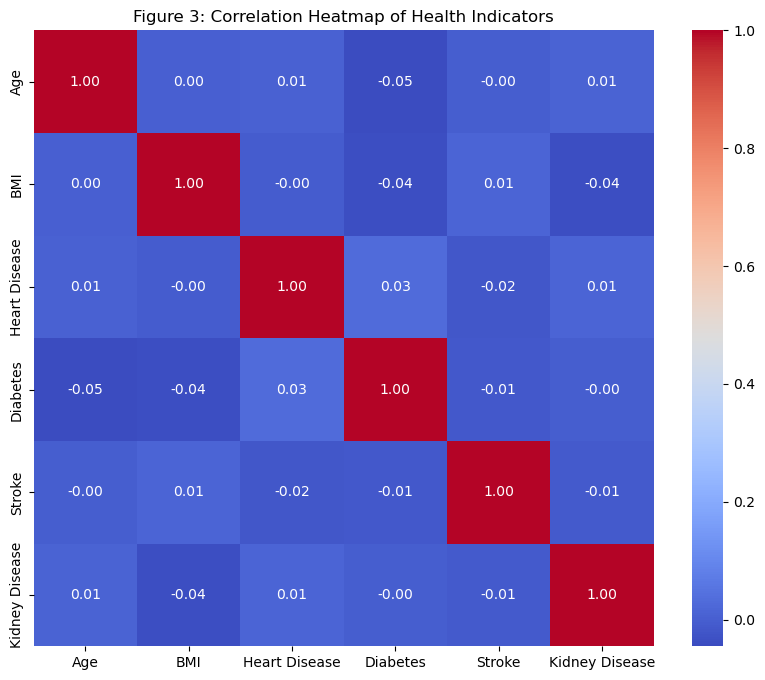

In [1]:
## Muhammad Hassan Iqbal
## 23100172
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

def load_and_clean_data(filename):
    df = pd.read_csv(filename)
    # Basic cleaning: remove rows with missing values
    df = df.dropna()
    return df

def calculate_moments(df, column):
    """Calculates Mean, Variance, Skewness, and Kurtosis."""
    data = df[column]
    m1 = np.mean(data)
    m2 = np.var(data)
    m3 = skew(data)
    m4 = kurtosis(data)
    return m1, m2, m3, m4

def plot_relational(df):
    """Relational Plot: Age vs BMI."""
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Age', y='BMI', hue='Heart Disease', alpha=0.7)
    plt.title('Figure 1: Age vs BMI Distribution by Heart Disease Status')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig('relational_plot.png')
    plt.show()  # <--- This displays the plot in your notebook

def plot_categorical(df):
    """Categorical Plot: Disease Prevalence."""
    disease_cols = ['Heart Disease', 'Diabetes', 'Stroke', 'Kidney Disease', 'Cancer', 
                    "Alzheimer's Disease", 'COPD', 'Liver Disease', "Parkinson's Disease", 'Tuberculosis']
    counts = df[disease_cols].sum().sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='magma', legend=False)
    plt.title('Figure 2: Prevalence of Chronic Conditions')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('categorical_plot.png')
    plt.show()  # <--- This displays the plot in your notebook

def plot_statistical(df):
    """Statistical Plot: Correlation Heatmap."""
    cols = ['Age', 'BMI', 'Heart Disease', 'Diabetes', 'Stroke', 'Kidney Disease']
    corr = df[cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Figure 3: Correlation Heatmap of Health Indicators')
    plt.savefig('statistical_plot.png')
    plt.show()  # <--- This displays the plot in your notebook

# --- Execution ---
file_path = r'C:\Users\AZFAR\OneDrive\Desktop\Bhatti\healthcare_disease_prediction_dataset.csv'
df = load_and_clean_data(file_path)

# Display Moments
for col in ['Age', 'BMI']:
    m1, m2, m3, m4 = calculate_moments(df, col)
    print(f"\n--- {col} Statistics ---")
    print(f"Mean: {m1:.2f} | Variance: {m2:.2f} | Skewness: {m3:.2f} | Kurtosis: {m4:.2f}")

# Generate Plots
plot_relational(df)
plot_categorical(df)
plot_statistical(df)